In [14]:
# STEP 1: Check raw values
print("Before cleaning:", df['churn'].unique())

# STEP 2: Clean properly
df['churn'] = df['churn'].astype(str)   # convert everything to string
df['churn'] = df['churn'].str.strip()   # remove spaces
df['churn'] = df['churn'].str.lower()   # lowercase

# STEP 3: Replace invalid values manually
df['churn'] = df['churn'].replace({
    'yes': 1,
    'no': 0,
    '': None,
    'nan': None,
    'none': None
})

# STEP 4: Convert to numeric
df['churn'] = pd.to_numeric(df['churn'], errors='coerce')

# STEP 5: DROP remaining NaN rows
df = df.dropna(subset=['churn'])

# STEP 6: Final check
print("After cleaning:", df['churn'].unique())
print("NaN count:", df['churn'].isnull().sum())

Before cleaning: [nan]
After cleaning: []
NaN count: 0


In [19]:
df['churn'] = df['churn'].astype(str).str.strip().str.lower()

# FIX mapping carefully
df['churn'] = df['churn'].replace({
    'yes': 1,
    'no': 0
})

In [18]:
# STEP 1: Check original values
print(df['churn'].unique())

[]


In [20]:
df['churn'] = df['churn'].fillna(0)   # or 1 if needed

In [17]:
# STEP 1: Check original values
print(df['churn'].unique())

[]


In [9]:
print(df['churn'].isnull().sum())

500


In [10]:
df['churn'] = df['churn'].astype(str).str.strip().str.lower()
df['churn'] = df['churn'].map({'yes': 1, 'no': 0})

In [11]:
# Clean target column
df['churn'] = df['churn'].astype(str).str.strip().str.lower()
df['churn'] = df['churn'].map({'yes': 1, 'no': 0})

# Remove NaN rows
df = df[df['churn'].notna()]

# Split
X = df.drop('churn', axis=1)
y = df['churn']

In [21]:
df['churn'] = df['churn'].astype(int)

In [22]:
print(df['churn'].value_counts())

Series([], Name: count, dtype: int64)


Dataset Shape: (500, 9)
  customerid  tenure  monthlycharges  totalcharges        contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      paymentmethod paperlessbilling  seniorcitizen  churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  
Churn values: [0 1]

Accuracy: 0.95

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97        84
           1       

C:\Users\punit\AppData\Local\Temp\ipykernel_27760\3901559496.py:58: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['churn'].fillna(0, inplace=True)


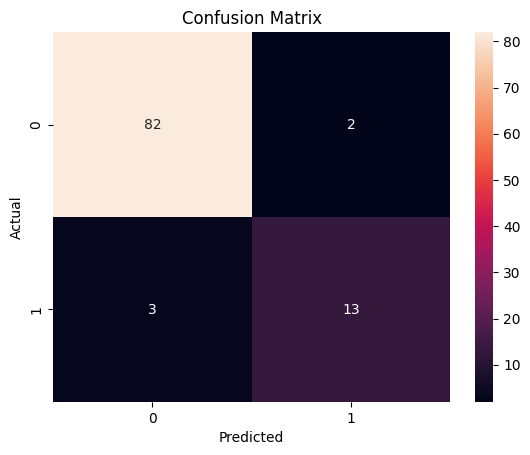

                          Feature  Importance
0                          tenure    0.631008
1                  monthlycharges    0.125371
2                    totalcharges    0.109772
4               contract_One year    0.043507
5               contract_Two year    0.032660
8            paperlessbilling_Yes    0.018051
3                   seniorcitizen    0.016702
6       paymentmethod_Credit Card    0.012869
7  paymentmethod_Electronic Check    0.010061


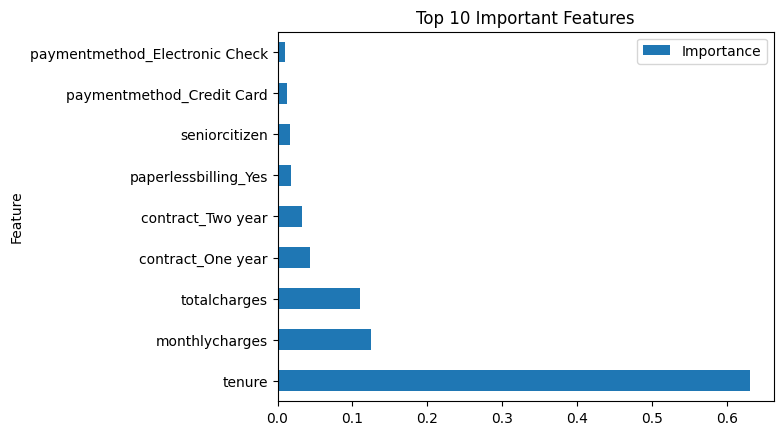

✅ Model saved successfully!
Sample Prediction: [0]


In [2]:
# =========================================
# 🚀 CAPSTONE PROJECT - CUSTOMER CHURN
# END-TO-END MACHINE LEARNING PIPELINE
# =========================================

# ✅ 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# =========================================
# ✅ 2. LOAD DATA
# =========================================
df = pd.read_csv("customer_churn.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("Dataset Shape:", df.shape)
print(df.head())

# =========================================
# ✅ 3. DATA CLEANING
# =========================================

# Convert totalcharges to numeric
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

# Fill missing values
df.fillna(0, inplace=True)

# Drop customerID
if 'customerid' in df.columns:
    df.drop('customerid', axis=1, inplace=True)

# =========================================
# ✅ 4. FIX TARGET COLUMN (VERY IMPORTANT)
# =========================================

df['churn'] = df['churn'].astype(str).str.strip().str.lower()

df['churn'] = df['churn'].replace({
    'yes': 1,
    'no': 0
})

df['churn'] = pd.to_numeric(df['churn'], errors='coerce')

# Fill any remaining NaN
df['churn'].fillna(0, inplace=True)

df['churn'] = df['churn'].astype(int)

print("Churn values:", df['churn'].unique())

# =========================================
# ✅ 5. ENCODING (CATEGORICAL → NUMERIC)
# =========================================
df = pd.get_dummies(df, drop_first=True)

# =========================================
# ✅ 6. FEATURE / TARGET SPLIT
# =========================================
X = df.drop('churn', axis=1)
y = df['churn']

# =========================================
# ✅ 7. TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# ✅ 8. FEATURE SCALING
# =========================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================
# ✅ 9. MODEL TRAINING
# =========================================
model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

# =========================================
# ✅ 10. PREDICTION
# =========================================
y_pred = model.predict(X_test)

# =========================================
# ✅ 11. EVALUATION
# =========================================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================
# ✅ 12. FEATURE IMPORTANCE
# =========================================
importances = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_df.head(10))

# Plot feature importance
feat_df.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.title("Top 10 Important Features")
plt.show()

# =========================================
# ✅ 13. SAVE MODEL
# =========================================
pickle.dump(model, open("model.pkl", "wb"))

print("✅ Model saved successfully!")

# =========================================
# ✅ 14. SIMPLE PREDICTION TEST
# =========================================
sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

print("Sample Prediction:", prediction)

In [3]:
# app.py

from flask import Flask, request, jsonify
import pickle

app = Flask(__name__)

model = pickle.load(open("model.pkl", "rb"))

@app.route("/")
def home():
    return "Churn Model Running"

@app.route("/predict", methods=["POST"])
def predict():
    data = request.json
    prediction = model.predict([list(data.values())])
    return jsonify({"prediction": int(prediction[0])})

if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1

C:\Users\punit\AppData\Roaming\Python\Python314\site-packages\IPython\core\interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [17]:
from sklearn.ensemble import RandomForestClassifier

def train_model(X_train, y_train):
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    return model

In [16]:
def clean_data(df):
    df.columns = df.columns.str.lower().str.strip()
    df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')
    df.fillna(0, inplace=True)
    return df